# A single water molecule  

For this we have a $V_{bond}$ (Harmonic Bond Stretching). So we need to implement:  
$$V_{bond}=\frac{1}{2} \sum_{l=1}^2 k\left(||q_{h_l}-q_o||-q_{e q}\right)^2$$

In [36]:
# Velocity Verlet integrator for molecular dynamics
import numpy as np

# velocity-verlet integrator that works for arbitrary particle counts and potentials

def velocity_verlet(q, p, masses, force_func, dt, num_steps):
    """Integrate Hamiltonian mechanics using velocity Verlet.

    Parameters
    ----------
    q : ndarray, shape (N, D)
        Initial positions of N particles in D dimensions.
    p : ndarray, shape (N, D)
        Initial momenta of the particles.
    masses : ndarray, shape (N,)
        Mass of each particle.
    force_func : callable
        Function `f(q)` returning forces array of shape (N, D).
    dt : float
        Time step.
    num_steps : int
        Number of steps to integrate.

    Returns
    -------
    traj_q : ndarray, shape (num_steps+1, N, D)
        Positions at each time step.
    traj_p : ndarray, shape (num_steps+1, N, D)
        Momenta at each time step.
    """
    q = np.array(q, dtype=float)
    p = np.array(p, dtype=float)
    masses = np.array(masses, dtype=float)
    n, dim = q.shape

    traj_q = np.zeros((num_steps + 1, n, dim))
    traj_p = np.zeros_like(traj_q)

    traj_q[0] = q
    traj_p[0] = p

    # precompute mass column for vectorized operations
    mcol = masses[:, None]

    f = force_func(q)
    for i in range(num_steps):
        # 1. update positions
        q = q + (p / mcol) * dt + 0.5 * (f / mcol) * dt ** 2
        # 2. half-step momentum
        p_half = p + 0.5 * f * dt
        # 3. compute new forces
        f = force_func(q)
        # 4. full-step momentum
        p = p_half + 0.5 * f * dt

        traj_q[i + 1] = q
        traj_p[i + 1] = p

    return traj_q, traj_p

In [37]:
import numpy as np

def compute_bond_potential(q, bond_list, k, q_eq):
    """
    Calculates the total bond potential energy.
    q: (N_total, 3) array of positions
    bond_list: (N_bonds, 2) array of atom index pairs
    """
    # 1. Get positions of the atoms involved in bonds
    i, j = bond_list[:, 0], bond_list[:, 1]
    
    # 2. Calculate distances
    dr = q[i] - q[j]
    r = np.linalg.norm(dr, axis=1)
    
    # 3. Apply the formula: 1/2 * k * (r - r0)^2
    # The sum handles the sigma in your formula
    energy = 0.5 * k * np.sum((r - q_eq)**2)
    return energy

def compute_bond_forces(q, bond_list, k, q_eq):
    """
    Calculates the forces acting on every atom due to bonds.
    """
    n_atoms = q.shape[0]
    forces = np.zeros((n_atoms, 3))
    
    i, j = bond_list[:, 0], bond_list[:, 1]
    
    # Vectorized relative vectors and distances
    dr = q[i] - q[j]
    r = np.linalg.norm(dr, axis=1, keepdims=True)
    
    # Force magnitude: -k * (r - r0)
    # The (dr / r) part is the unit vector direction
    f_magnitude = -k * (r - q_eq)
    f_vectors = f_magnitude * (dr / r)
    
    # Scatter the forces back into the main array
    # np.add.at is used to handle atoms that have multiple bonds (like Oxygen)
    np.add.at(forces, i, f_vectors)
    np.add.at(forces, j, -f_vectors)
    
    return forces



In [38]:
def compute_angle_forces(q, angle_list, k_theta, theta_eq):
    n_atoms = q.shape[0]
    forces = np.zeros((n_atoms, 3))
    
    # Indices for O, H1, H2
    idx_o, idx_h1, idx_h2 = angle_list[:,0], angle_list[:,1], angle_list[:,2]
    
    r1 = q[idx_h1] - q[idx_o]
    r2 = q[idx_h2] - q[idx_o]
    
    d1 = np.linalg.norm(r1, axis=1, keepdims=True)
    d2 = np.linalg.norm(r2, axis=1, keepdims=True)
    
    # Normalize vectors
    u1 = r1 / d1
    u2 = r2 / d2
    
    # Compute theta
    cos_theta = np.sum(u1 * u2, axis=1, keepdims=True)
    cos_theta = np.clip(cos_theta, -1.0, 1.0) # Numerical safety
    theta = np.arccos(cos_theta)
    
    # Precompute coefficient: -k_theta * (theta - theta_eq) / sin(theta)
    sin_theta = np.sqrt(1 - cos_theta**2)
    # Avoid division by zero if theta is exactly 0 or pi
    sin_theta = np.where(sin_theta < 1e-8, 1e-8, sin_theta)
    
    coeff = -k_theta * (theta - theta_eq) / sin_theta
    
    # Calculate force vectors
    f_h1 = (coeff / d1) * (u2 - cos_theta * u1)
    f_h2 = (coeff / d2) * (u1 - cos_theta * u2)
    f_o = -(f_h1 + f_h2)
    
    # Accumulate into global force array
    np.add.at(forces, idx_h1, f_h1)
    np.add.at(forces, idx_h2, f_h2)
    np.add.at(forces, idx_o, f_o)
    
    return forces

In [39]:
def water_molecule_forces(q):
    # Calculate bond forces
    f_bonds = compute_bond_forces(q, bond_list, k_bond, r_eq)
    
    # Calculate angle forces
    f_angles = compute_angle_forces(q, angle_list, k_theta, theta_eq)
    
    # The total internal force is the sum
    return f_bonds + f_angles

In [40]:
import numpy as np

# --- 1. System Parameters ---
# (Replace these with the exact numbers from your Project PDF)
m_O = 15.999
m_H = 1.008
r_eq = 1.0        # Equilibrium bond length
theta_eq = np.deg2rad(104.52) # Equilibrium angle in radians
k_bond = 1000.0   # Spring constant for bond
k_theta = 500.0   # Spring constant for angle

masses = np.array([m_O, m_H, m_H])

# Lists for our topology
bond_list = np.array([[1, 0], [2, 0]]) # H1-O and H2-O
angle_list = np.array([[0, 1, 2]])     # O is center, H1, H2

# --- 2. Initial Positions (Equilibrium + small stretch) ---
# We place O at the origin, H1 along the x-axis, and H2 at the correct angle.
q_init = np.array([
    [0.0, 0.0, 0.0],                                  # Oxygen
    [r_eq + 0.1, 0.0, 0.0],                           # H1 (stretched by 0.1)
    [r_eq * np.cos(theta_eq), r_eq * np.sin(theta_eq), 0.0] # H2 (equilibrium)
])

# --- 3. Initial Momenta (Start at rest) ---
p_init = np.zeros((3, 3))

In [41]:
# --- 4. Integrate ---
dt = 0.001       # Small time step!
num_steps = 5000 # Run for 5000 steps

traj_q, traj_p = velocity_verlet(
    q=q_init, 
    p=p_init, 
    masses=masses, 
    force_func=water_molecule_forces, 
    dt=dt, 
    num_steps=num_steps
)

print(f"Simulation finished! Trajectory shape: {traj_q.shape}")

Simulation finished! Trajectory shape: (5001, 3, 3)


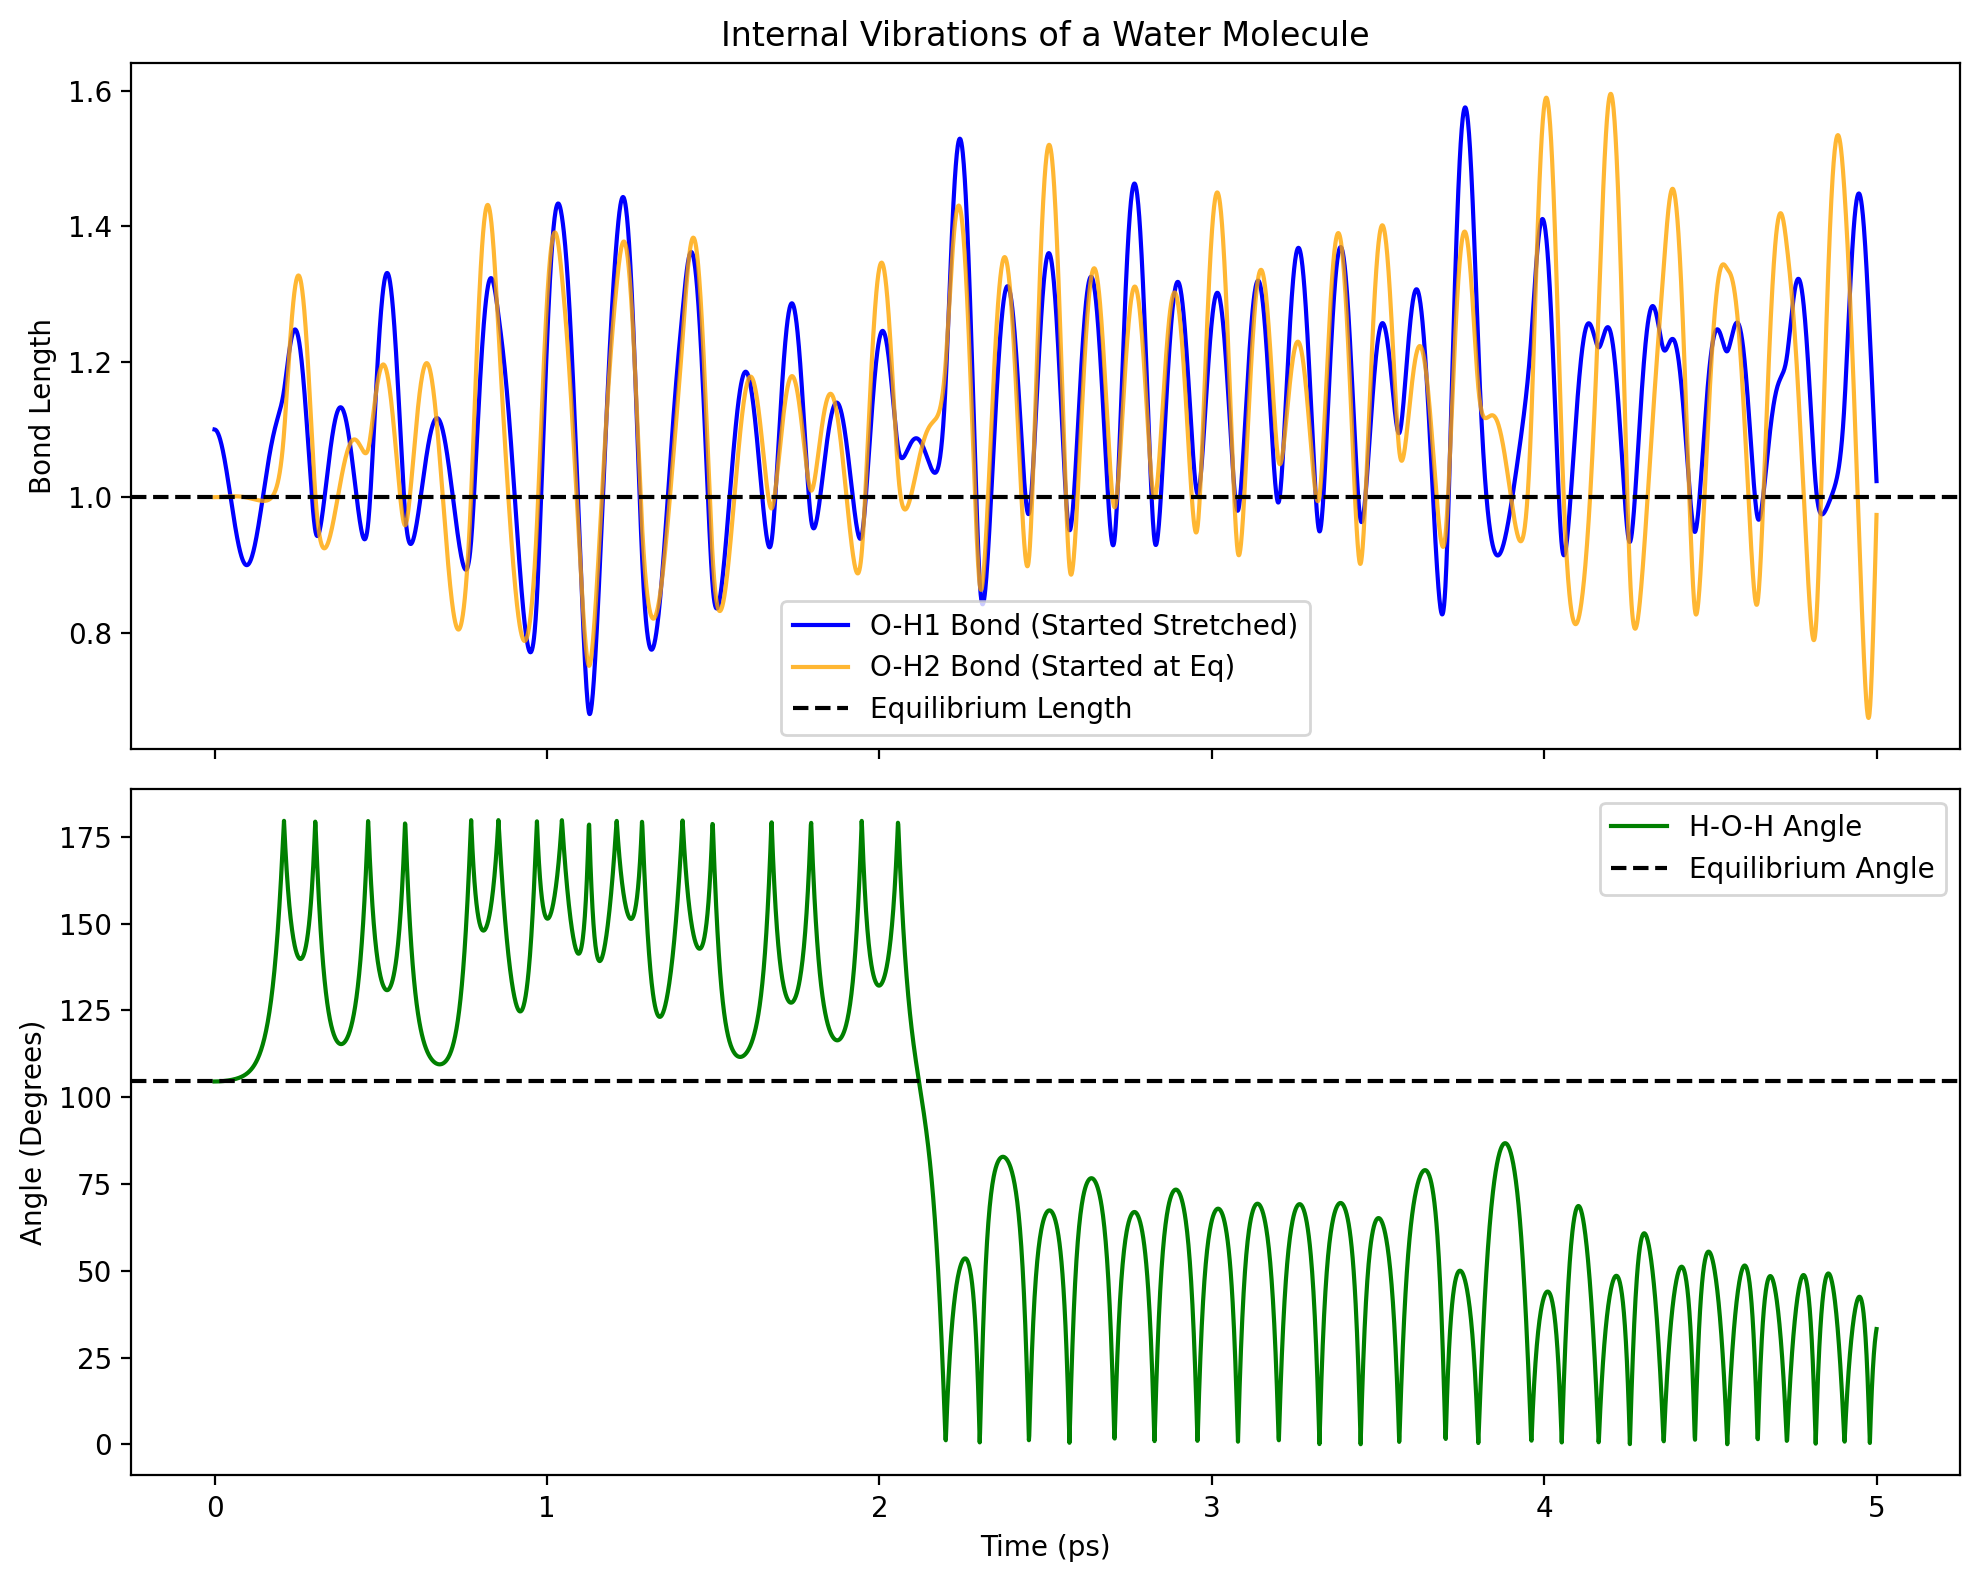

In [43]:
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'
import numpy as np

# 1. Extract the trajectories for each atom
# traj_q shape is (num_steps + 1, 3 atoms, 3 dimensions)
q_O  = traj_q[:, 0, :]
q_H1 = traj_q[:, 1, :]
q_H2 = traj_q[:, 2, :]

# 2. Calculate Bond Distances over time
# Vector from O to H1 and O to H2
v1 = q_H1 - q_O
v2 = q_H2 - q_O

# Distances (using np.linalg.norm along the spatial axis)
dist_OH1 = np.linalg.norm(v1, axis=1)
dist_OH2 = np.linalg.norm(v2, axis=1)

# 3. Calculate the Angle over time
# cos(theta) = (v1 dot v2) / (|v1| * |v2|)
dot_product = np.sum(v1 * v2, axis=1)
cos_theta = dot_product / (dist_OH1 * dist_OH2)

# Convert to degrees for easier reading
angle_deg = np.degrees(np.arccos(cos_theta))

# 4. Create the Time Array
# (Assuming dt = 0.001 from our previous setup)
time = np.arange(len(dist_OH1)) * dt

# 5. Plot the Results
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Top Plot: Bond Lengths
ax1.plot(time, dist_OH1, label='O-H1 Bond (Started Stretched)', color='blue')
ax1.plot(time, dist_OH2, label='O-H2 Bond (Started at Eq)', color='orange', alpha=0.8)
ax1.axhline(r_eq, color='k', linestyle='--', label='Equilibrium Length')
ax1.set_ylabel('Bond Length')
ax1.set_title('Internal Vibrations of a Water Molecule')
ax1.legend()

# Bottom Plot: Bond Angle
ax2.plot(time, angle_deg, label='H-O-H Angle', color='green')
ax2.axhline(np.degrees(theta_eq), color='k', linestyle='--', label='Equilibrium Angle')
ax2.set_xlabel('Time (ps)')
ax2.set_ylabel('Angle (Degrees)')
ax2.legend()

plt.tight_layout()
plt.show()

In [17]:
# Parameters from your notes
k_bond = 1059.162  # Example value for SPC water
q_eq = 1.0         # Equilibrium bond length

# 1. Define positions (N=6 atoms, 3 per molecule)
# Placing them roughly in a line for this example
q = np.array([
    [0.0, 0.0, 0.0], [1.1, 0.0, 0.0], [-1.1, 0.0, 0.0], # Molecule 1 (stretched)
    [5.0, 0.0, 0.0], [6.0, 0.0, 0.0], [4.0, 0.0, 0.0]  # Molecule 2 (equilibrium)
])


# 2. Define the Bond List
# This list tells the code: "Atoms 1 and 0 are bonded, 2 and 0 are bonded, etc."
bonds = np.array([
    [1, 0], [2, 0],  # Bonds for Molecule 1
    [4, 3], [5, 3]   # Bonds for Molecule 2
])
# Assuming the pattern O, H1, H2, O, H1, H2...
# i is the index of the Oxygen atom for each molecule
if False:
    N = 6
    bond_list = np.array([[3*i, 3*i+1] for i in range(N)] + 
                         [[3*i, 3*i+2] for i in range(N)])

# 3. Calculate!
total_v = compute_bond_potential(q, bonds, k_bond, q_eq)
forces = compute_bond_forces(q, bonds, k_bond, q_eq)

print(f"Total Bond Potential: {total_v:.4f}")
print("Forces on atoms:\n", forces)

Total Bond Potential: 10.5916
Forces on atoms:
 [[   0.        0.        0.    ]
 [-105.9162    0.        0.    ]
 [ 105.9162    0.        0.    ]
 [   0.        0.        0.    ]
 [   0.        0.        0.    ]
 [   0.        0.        0.    ]]
